### El propósito de este análisis exploratorio es poder explorar y conocer mas acerca de la base dada. Como objetivo principal de la semana, se analizarán distribuciones de fill rates, causas frecuentes y top vendors. Como objetivos secundarios se busca analizar el impacto verdadero y las perdidas con el problema. 

### Primero se cargara la base y se dara un poco de contexto de la misma (esto a traves del README)

In [ ]:
#importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#carga de datos
df = pd.read_csv('.data/vendor_fill_rate_synthetic.csv')
print(df.info())
#para mas informacion de las columnas, consultar el README

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   VENDOR_NAME             400 non-null    str    
 1   VENDOR_NBR              400 non-null    int64  
 2   SKU_NBR                 400 non-null    int64  
 3   DC_ID                   400 non-null    str    
 4   PO_NBR                  400 non-null    int64  
 5   FISCAL_WEEK_NBR         400 non-null    int64  
 6   MDSE_GRP_DSC            400 non-null    str    
 7   DIRECTOR                400 non-null    str    
 8   CAT_NBR                 400 non-null    int64  
 9   CATEGORY                400 non-null    str    
 10  SKU_DSC                 400 non-null    str    
 11  DNP_RANKING             400 non-null    str    
 12  COMBINED_ACTION         400 non-null    str    
 13  COMBINED_CAUSE          400 non-null    str    
 14  ACTION_TAKEN_ON_TIME    264 non-null    str    
 15  

In [13]:
#Se hara una limpieza de la base, eliminando columnas que no son necesarias para el analisis y solo dejando las consideradas relevantes en el README
#columnas_relevantes = ['FILL_RATE', 'COMBINED_CAUSE', 'VENDOR_NBR', 'NEW_ISSUE_FLAG', 'STORE_COUNT', 'DNP_RANKING', 'SKU_AVG_MARGIN']
#df_limpio = df[columnas_relevantes]

#Antes de crear la base limpia se comparara con el README para verificar la existencia de las columnas, ya que se encontraron inconsistencias.

### Empezaremos a analizar distribuciones de las columnas

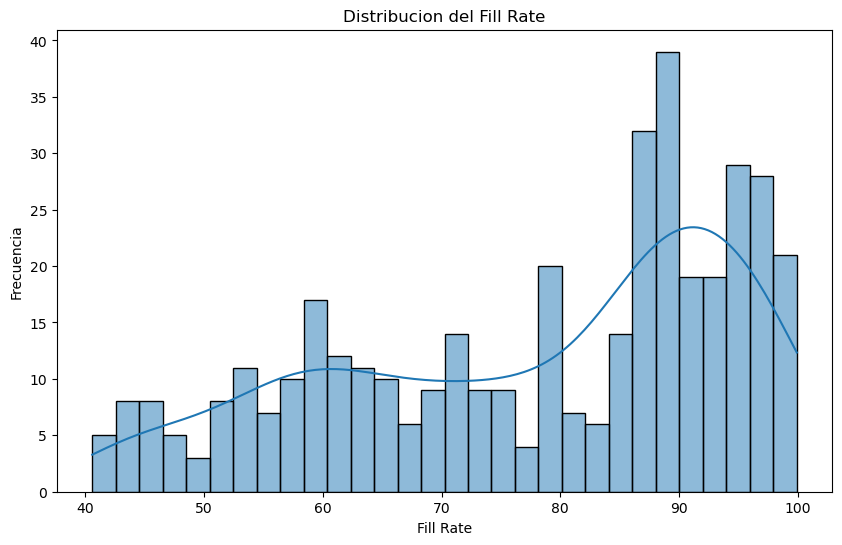

In [8]:
#Primero la distribucion de el fill rate
plt.figure(figsize=(10,6))
sns.histplot(df['FILL_RATE'], bins=30, kde=True)
plt.title('Distribucion del Fill Rate')
plt.xlabel('Fill Rate')
plt.ylabel('Frecuencia')
plt.show()

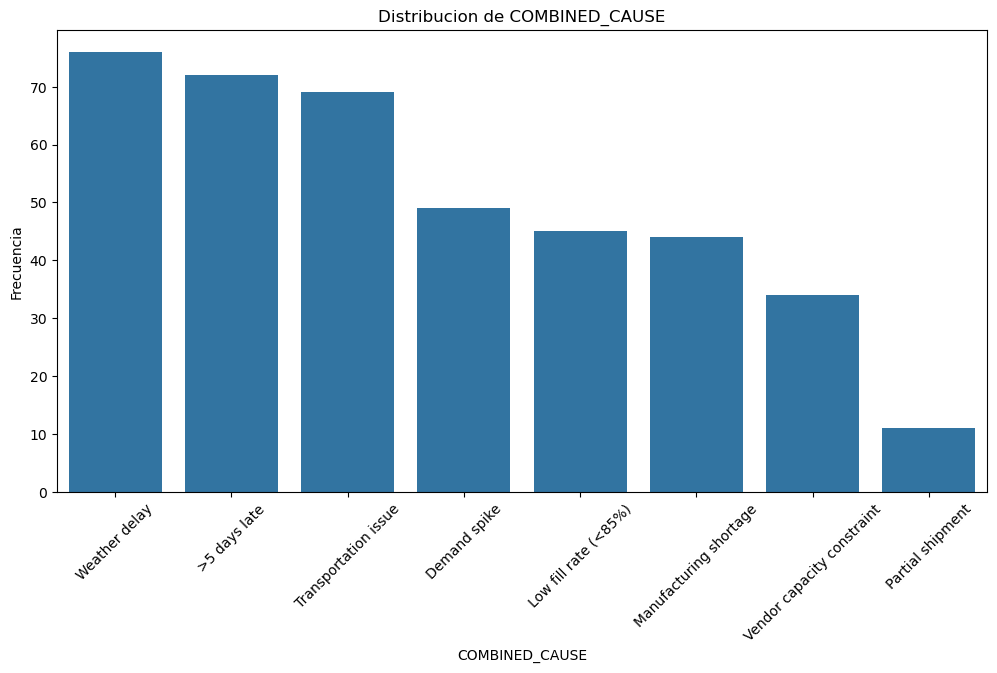

In [9]:
#Distribucion de COMBINED_CAUSE
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='COMBINED_CAUSE', order=df['COMBINED_CAUSE'].value_counts().index)
plt.title('Distribucion de COMBINED_CAUSE')
plt.xlabel('COMBINED_CAUSE')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

Gracias a esta grafica tambien podemos ver cuales son las causas principales de retraso 

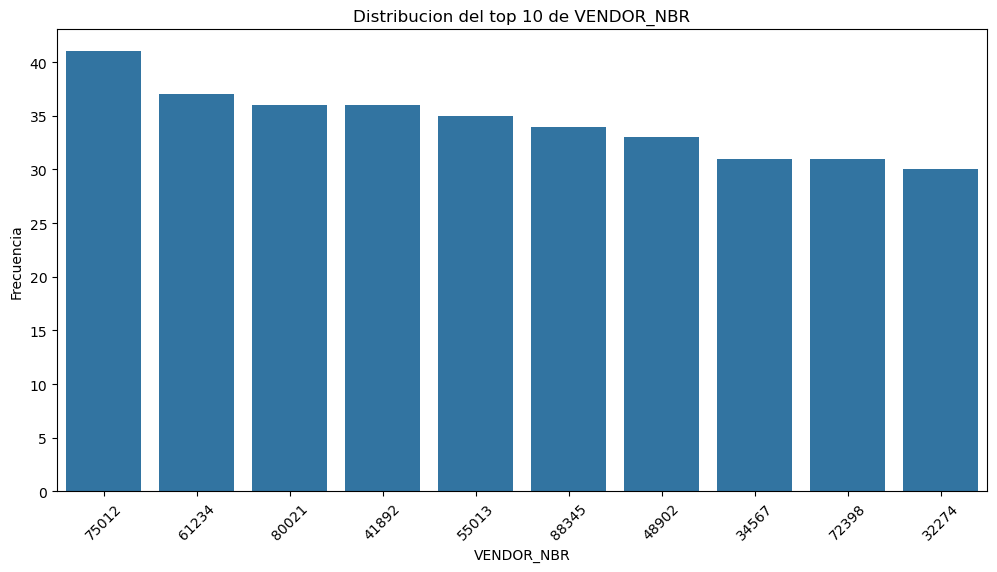

In [17]:
#Distribucion del top 10 de VENDOR_NBR con el nombre del proveedor
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='VENDOR_NBR', order=df['VENDOR_NBR'].value_counts().index[:10])
plt.title('Distribucion del top 10 de VENDOR_NBR')
plt.xlabel('VENDOR_NBR')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

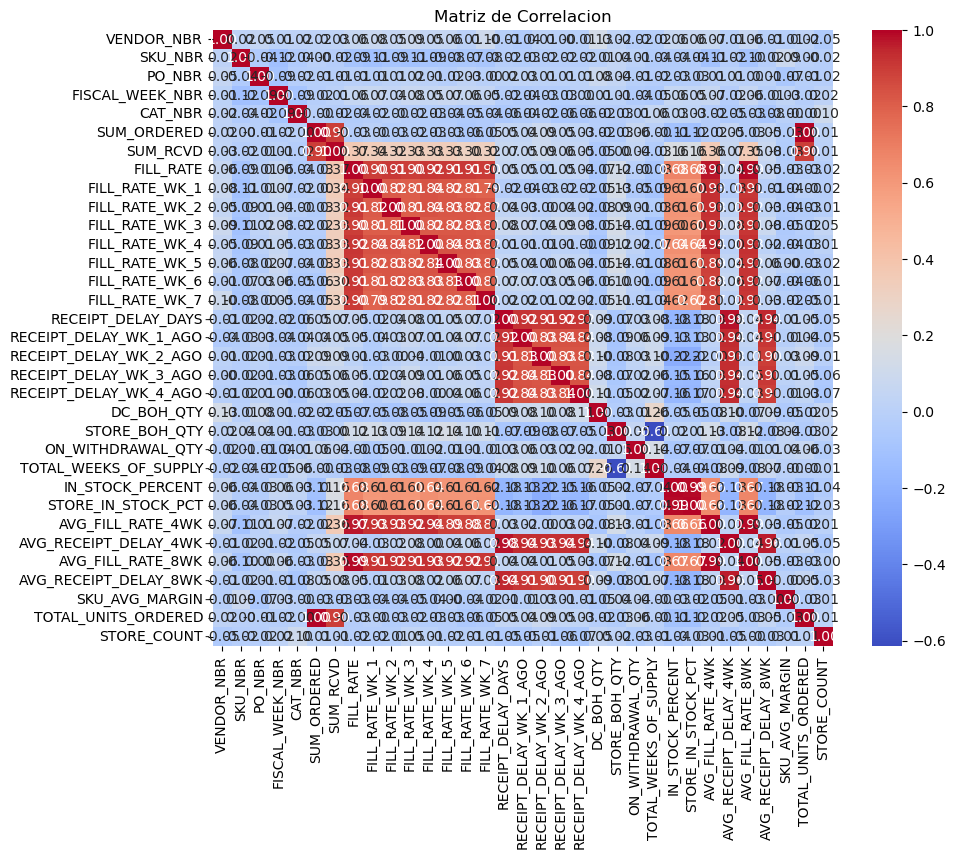

In [14]:
# Analisis de correlacion entre el fill rate y otras variables numericas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion')
plt.show()

### Definicion de las reglas para poder clasificar en "Python puro"